In [3]:
# =============================================================
# NOTEBOOK 01: Data Exploration
# Author: Vaishnav
# Purpose: Understand the raw Rossman dataset before any cleaning or modelling.
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.figsize'] = (12,6)

In [4]:
# LOAD THE RAW DATA

train_df = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store_df = pd.read_csv('../data/raw/store.csv')

print(f"training data shape: {train_df.shape}")
print(f"Store data shape: {store_df.shape}")

C:\Users\vaiis\AppData\Local\Temp\ipykernel_21320\4132697496.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])


training data shape: (1017209, 9)
Store data shape: (1115, 10)


In [5]:
# FIRST LOOK AT THE DATA
print("=== TRAINING DATA - First five rows ===")
print(train_df.head())

print("\n=== STORE DATA - First 5 rows ===")
print(store_df.head)

=== TRAINING DATA - First five rows ===
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

=== STORE DATA - First 5 rows ===
<bound method NDFrame.head of       Store StoreType Assortment  CompetitionDistance  \
0         1         c          a               1270.0   
1         2         a          a                570.0   
2         3         a          a              14130.0   
3         4         c          c                620.0   
4         5         a      

In [6]:
# UNDERSTAND DATA TYPES AND MISSING VALUES

print("=== TRAINING DATA INFO ===")
train_df.info()

print("\n=== STORE DATA INFO ===")
store_df.info()

=== TRAINING DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB

=== STORE DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------         

In [7]:
# STATISTICAL SUMMARY
print("=== TRAINING DATA - Statistical Summary ===")
train_df.describe()

=== TRAINING DATA - Statistical Summary ===


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [8]:
# INVESTIGATE ZERO SALES 

zero_sales = train_df[train_df['Sales'] == 0]

print(f"Total rows with zero sales: {len(zero_sales)}")
print(f"Percentage of total data: {len(zero_sales)/len(train_df)*100:.2f}%")

print(f"\nZero sales where store was OPEN: {len(zero_sales[zero_sales['Open'] == 1])}")
print(f"Zero sales where store was CLOSED: {len(zero_sales[zero_sales['Open'] == 0])}")

Total rows with zero sales: 172871
Percentage of total data: 16.99%

Zero sales where store was OPEN: 54
Zero sales where store was CLOSED: 172817


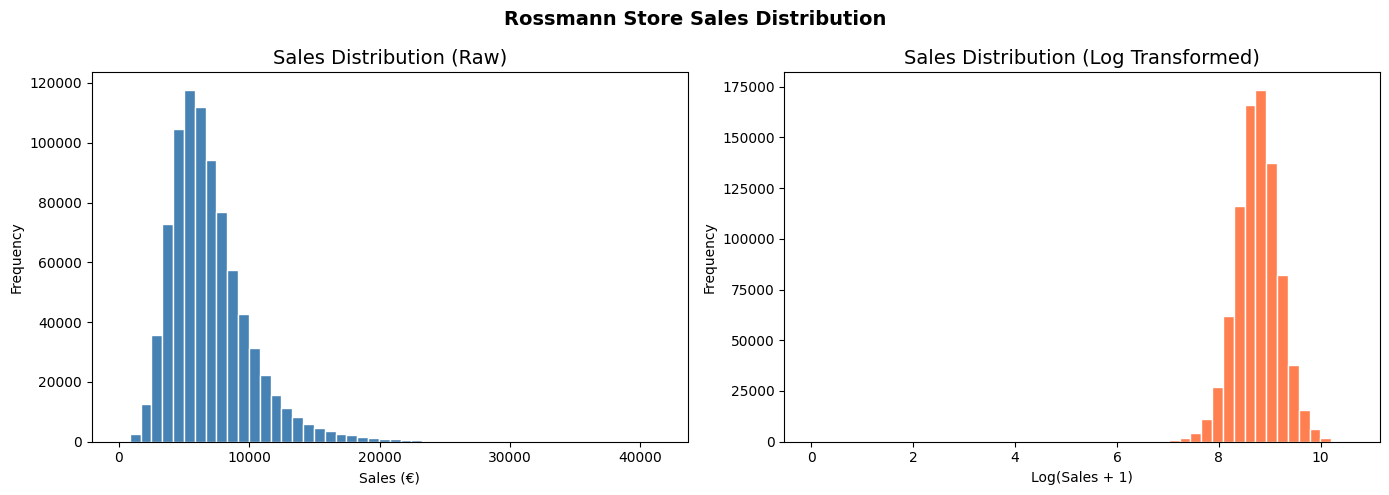

In [9]:
# Visualize sales Distribution

open_stores = train_df[train_df['Open'] == 1]
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Chart 1: Raw sales distribution
axes[0].hist(open_stores['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (Raw)', fontsize=14)
axes[0].set_xlabel('Sales (€)')
axes[0].set_ylabel('Frequency')

#Chart2: Log Transformed Sales
axes[1].hist(np.log1p(open_stores['Sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sales Distribution (Log Transformed)', fontsize=14)
axes[1].set_xlabel('Log(Sales + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Rossmann Store Sales Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

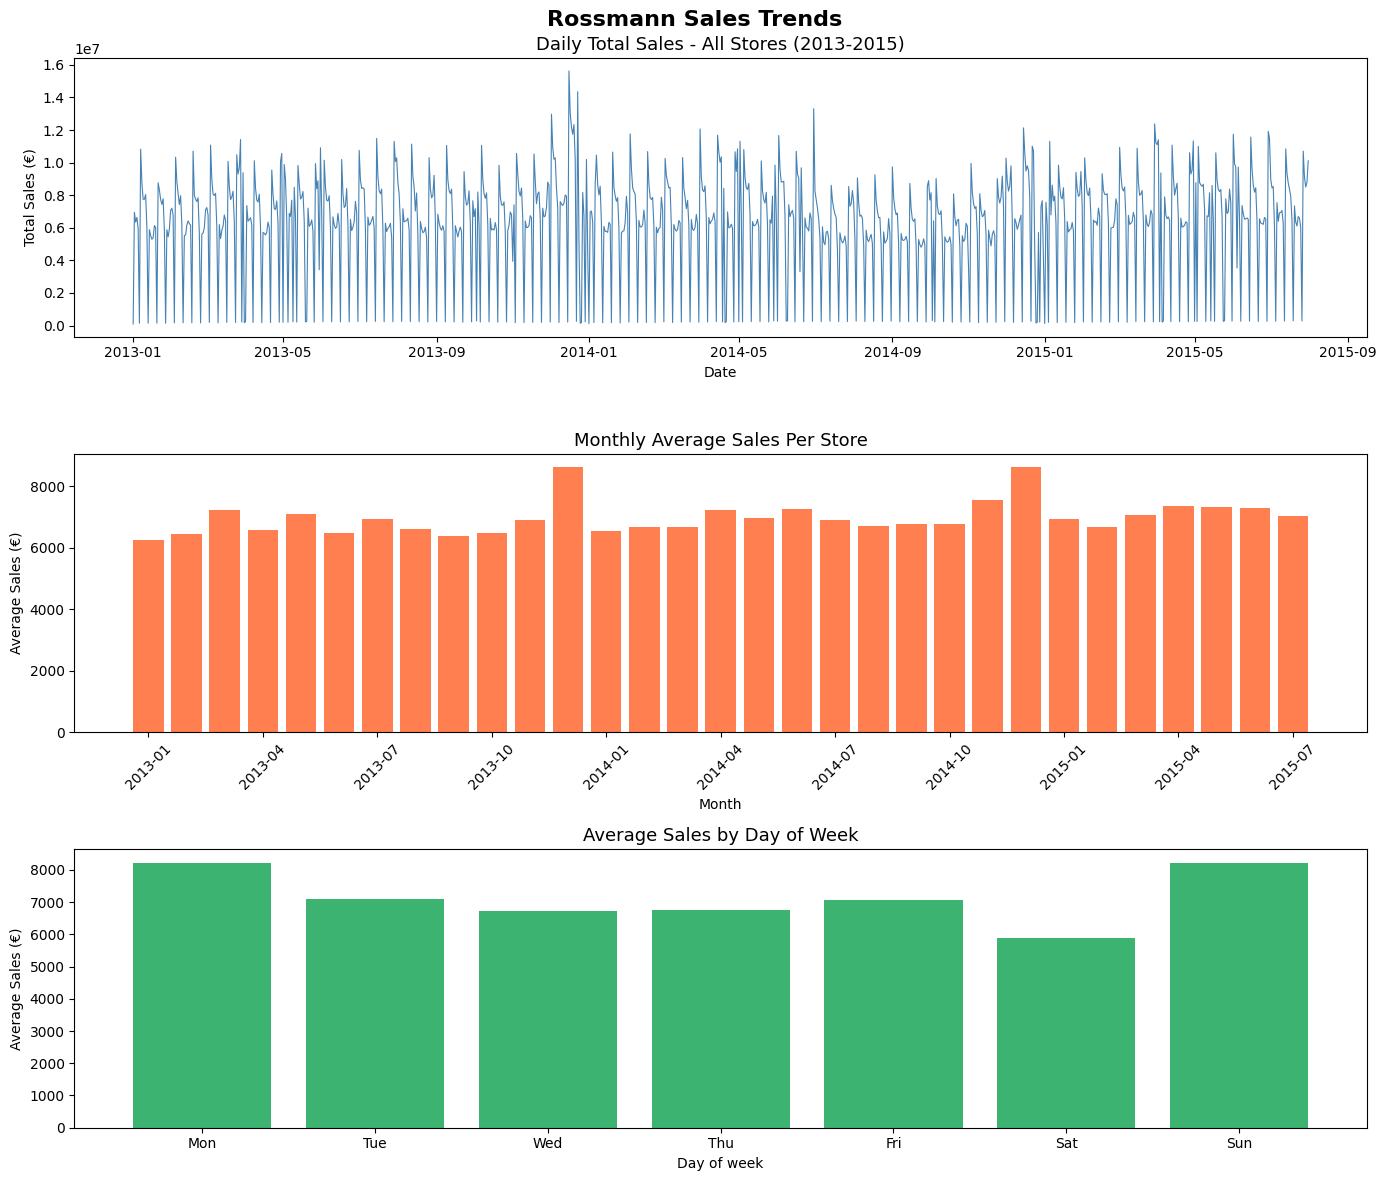

In [10]:
# Sales trend over time

open_df = train_df[train_df['Open'] == 1].copy()

daily_sales = open_df.groupby('Date')["Sales"].sum().reset_index()

# Plot
fig, axes =plt.subplots(3, 1, figsize=(14, 12))

# Chart 1: Overall daily sales trend
axes[0].plot(daily_sales['Date'], daily_sales['Sales'], color='steelblue', linewidth=0.8)
axes[0].set_title('Daily Total Sales - All Stores (2013-2015)', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales (€)')

# Chart 2: Monthly average sales
monthly_sales = open_df.groupby(open_df['Date'].dt.to_period('M'))['Sales'].mean()
axes[1].bar(range(len(monthly_sales)), monthly_sales.values, color='coral')
axes[1].set_title('Monthly Average Sales Per Store', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Sales (€)')
axes[1].set_xticks(range(0, len(monthly_sales), 3))
axes[1].set_xticklabels([str(m) for m in monthly_sales.index[::3]], rotation=45)

# Chart 3: Average sales by day of week
dow_sales = open_df.groupby('DayOfWeek')['Sales'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].bar(day_names, dow_sales.values, color='mediumseagreen')
axes[2].set_title('Average Sales by Day of Week', fontsize=13)
axes[2].set_xlabel('Day of week')
axes[2].set_ylabel('Average Sales (€)')

plt.suptitle('Rossmann Sales Trends', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/sales_trends.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\vaiis\AppData\Local\Temp\ipykernel_21320\1109051975.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(promo_data, labels=['No Promo', 'Promo'],


Average sales WITHOUT promo: €5,929
Average sales WITH promo: €8,228
Promo sales lift: 38.8%


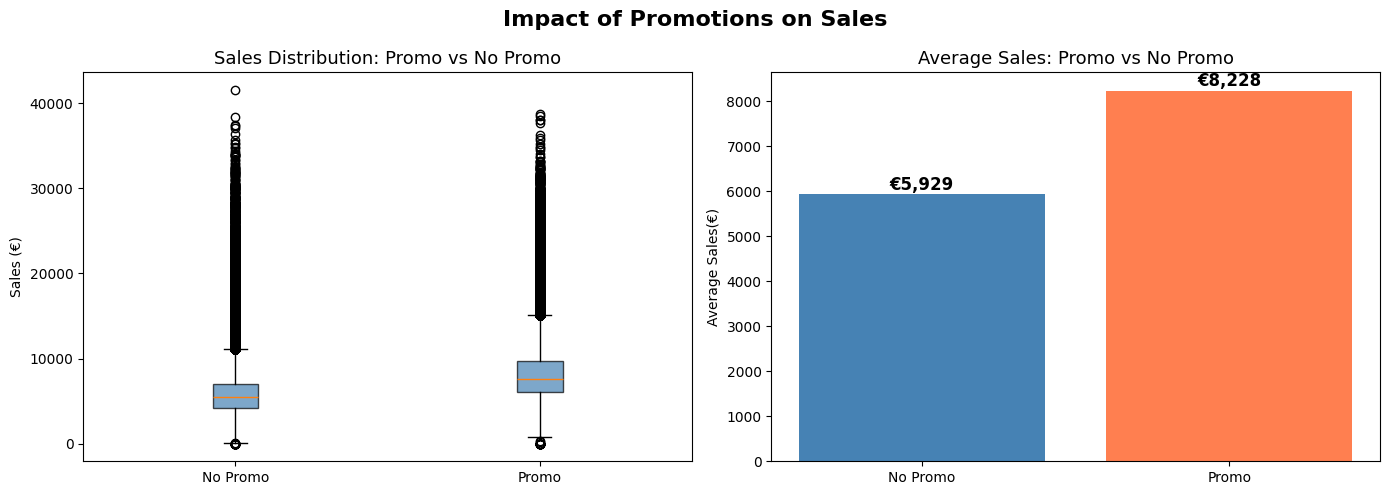

In [12]:
# Promo impact analysis

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Chart 1: sales with vs without promo
promo_data = [
    open_df[open_df['Promo'] == 0]['Sales'],
    open_df[open_df['Promo'] == 1]['Sales']
]

axes[0].boxplot(promo_data, labels=['No Promo', 'Promo'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Sales Distribution: Promo vs No Promo', fontsize=13)
axes[0].set_ylabel('Sales (€)')

# Chart 2: Average sales lift from promo
promo_avg = open_df.groupby('Promo')['Sales'].mean()
bars = axes[1].bar(['No Promo', 'Promo'], promo_avg.values,
                   color=['steelblue', 'coral'])
axes[1].set_title('Average Sales: Promo vs No Promo',fontsize=13)
axes[1].set_ylabel('Average Sales(€)')

for bar, val in zip(bars, promo_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 100,
                 f'€{val:,.0f}',
                 ha='center', fontsize=12, fontweight='bold')
    
# Calculate and print the lift percentage
lift = (promo_avg[1] - promo_avg[0]) / promo_avg[0] * 100
print(f"Average sales WITHOUT promo: €{promo_avg[0]:,.0f}")
print(f"Average sales WITH promo: €{promo_avg[1]:,.0f}")
print(f"Promo sales lift: {lift:.1f}%")

plt.suptitle('Impact of Promotions on Sales', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/promo_impact.png', dpi=150, bbox_inches='tight')
plt.show()